In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"yasasashinsana","key":"6b8e9a4ec477707b1400d364996ac4a8"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle competitions download -c dogs-vs-cats
!unzip -q dogs-vs-cats.zip
!unzip -q train.zip

100% 812M/812M [00:07<00:00, 115MB/s]



In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

dataset_path = "/content/train" # Path of unzipped file

###8: Average Image Analysis

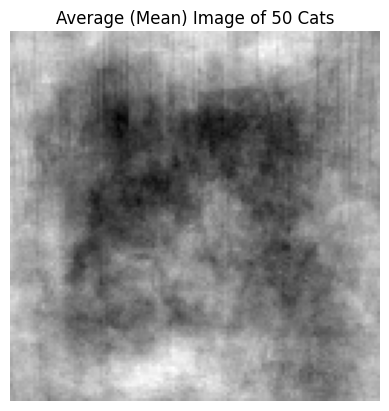

In [5]:
# --- Average Image Analysis: Cats ---
cat_images = []
# Get first 50 cat images to find the average
for file in os.listdir(dataset_path):
    if 'cat' in file and len(cat_images) < 50:
        img = cv2.imread(os.path.join(dataset_path, file), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (128, 128))
        cat_images.append(img)

# Calculate mean image
cat_images_array = np.array(cat_images)
mean_cat_image = np.mean(cat_images_array, axis=0)

# EDA Visualization
plt.imshow(mean_cat_image, cmap='gray')
plt.title('Average (Mean) Image of 50 Cats')
plt.axis('off')
plt.show()

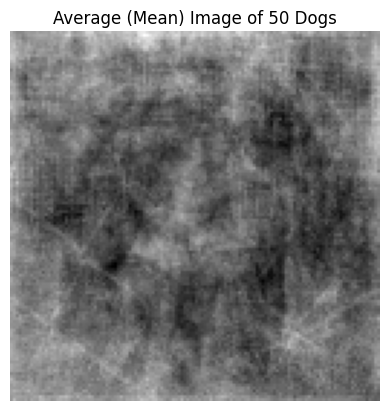

In [6]:
# --- Average Image Analysis: Dogs ---
dog_images = []
for file in os.listdir(dataset_path):
    if 'dog' in file and len(dog_images) < 50:
        img = cv2.imread(os.path.join(dataset_path, file), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (128, 128))
        dog_images.append(img)

dog_images_array = np.array(dog_images)
mean_dog_image = np.mean(dog_images_array, axis=0)

plt.imshow(mean_dog_image, cmap='gray')
plt.title('Average (Mean) Image of 50 Dogs')
plt.axis('off')
plt.show()

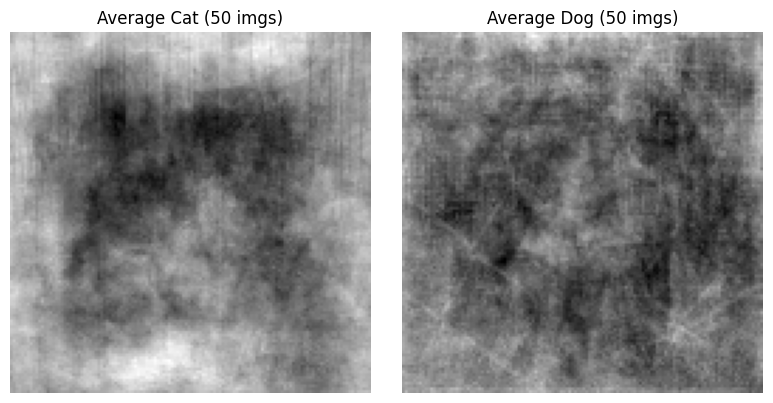

In [7]:
# --- Side-by-side comparison ---
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(mean_cat_image, cmap='gray')
axes[0].set_title('Average Cat (50 imgs)')
axes[0].axis('off')

axes[1].imshow(mean_dog_image, cmap='gray')
axes[1].set_title('Average Dog (50 imgs)')
axes[1].axis('off')

plt.tight_layout()
plt.show()